In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. Load and Denoise Image
def load_and_denoise(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    denoised = cv2.GaussianBlur(gray, (5, 5), 0)
    return img, denoised

In [ ]:
# 2. Edge Detection
def detect_edges(image):
    # Canny Edge Detection
    edges = cv2.Canny(image, 100, 200)

    # Sobel Operators
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Convert to uint8
    sobel_x = np.uint8(np.absolute(sobel_x))
    sobel_y = np.uint8(np.absolute(sobel_y))

    # Combine Sobel
    combined_sobel = cv2.bitwise_or(sobel_x, sobel_y)

    return edges, sobel_x, sobel_y, combined_sobel

In [ ]:
# 3. Display Edges
def display_edges(original, edges, horizontal, vertical, combined):
    plt.figure(figsize=(20, 10))

    plt.subplot(231), plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title('Original Image'), plt.axis('off')

    plt.subplot(232), plt.imshow(edges, cmap='gray')
    plt.title('Canny Edges'), plt.axis('off')

    plt.subplot(233), plt.imshow(horizontal, cmap='gray')
    plt.title('Horizontal Edges'), plt.axis('off')

    plt.subplot(234), plt.imshow(vertical, cmap='gray')
    plt.title('Vertical Edges'), plt.axis('off')

    plt.subplot(235), plt.imshow(combined, cmap='gray')
    plt.title('Combined Edges'), plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# 4. Fourier Transform on Boundary
def fourier_transform_boundary(image):
    # Find contours
    contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    # Get largest contour
    contour = max(contours, key=cv2.contourArea)
    contour = contour.squeeze()

    z = contour[:, 0] + 1j * contour[:, 1]


    # Apply FFT
    fft_coeffs = np.fft.fft(z)

    return z, fft_coeffs

In [ ]:
# 5. Reconstruct with Different Coefficients
def reconstruct_boundary(fft_coeffs, k_values=[5, 20, 100]):
    reconstructions = []

    for k in k_values:
        # Truncate coefficients
        truncated = fft_coeffs.copy()
        truncated[k:-k] = 0

        # Inverse FFT
        reconstructed = np.fft.ifft(truncated)
        reconstructions.append(reconstructed)

    return reconstructions

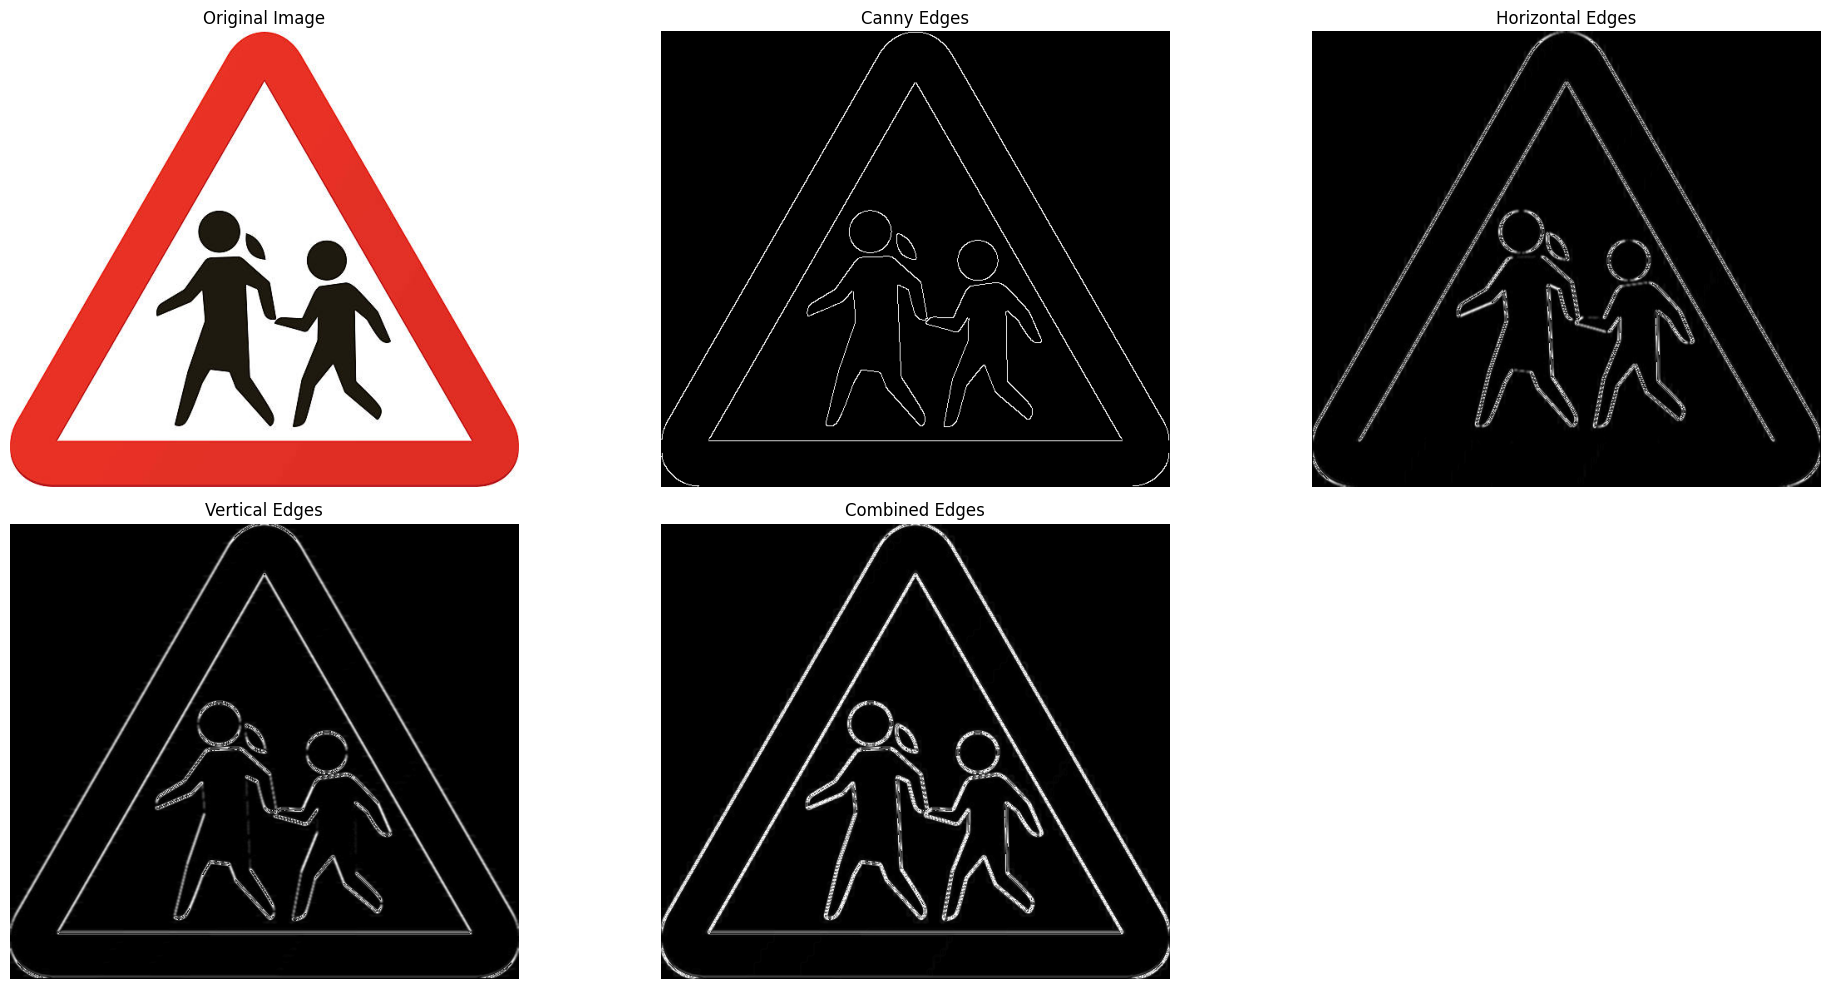

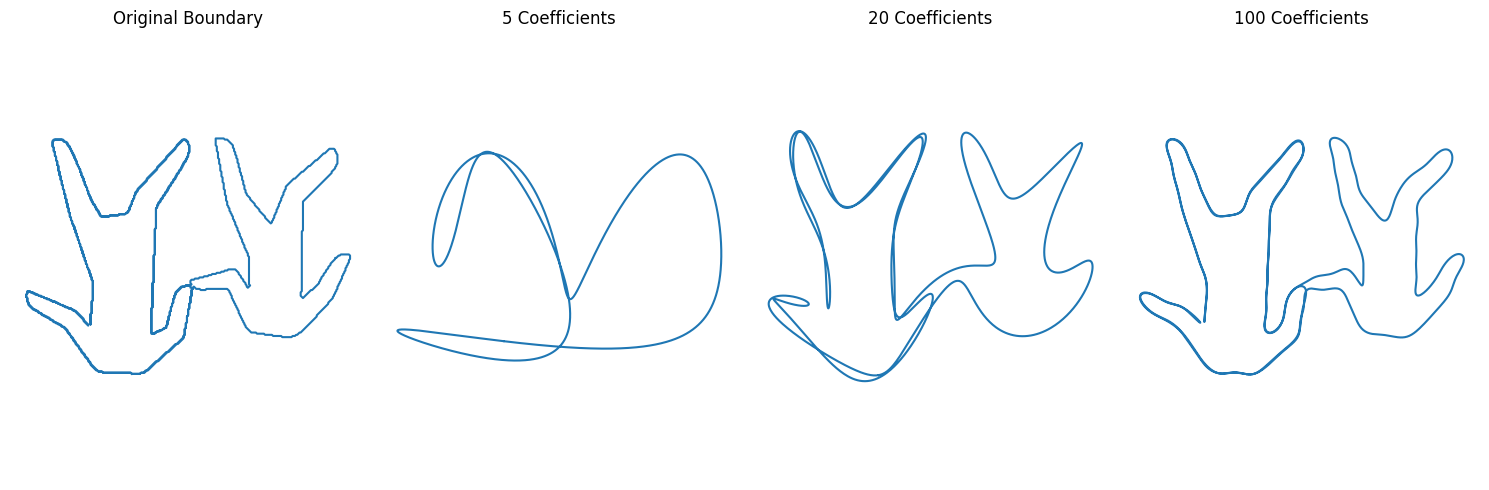


Applications of FFT:
- Signal filtering and frequency analysis
- Image compression (JPEG)
- Audio processing (MP3 compression)
- MRI image reconstruction
- Wireless communications (OFDM)


In [ ]:
# Main Processing
if __name__ == "__main__":
    # Load and denoise
    original, denoised = load_and_denoise('traffic_sign.jpg')

    # Edge detection
    edges, sobel_x, sobel_y, combined_sobel = detect_edges(denoised)

    # Display results
    display_edges(original, edges, sobel_x, sobel_y, combined_sobel)

    # Fourier analysis
    contour_points, fft_coeffs = fourier_transform_boundary(edges)

    # Reconstruct with different coefficients
    k_values = [5, 20, 100]
    reconstructed = reconstruct_boundary(fft_coeffs, k_values)

    # Plot reconstructions
    plt.figure(figsize=(15, 5))

    # Original contour
    plt.subplot(141), plt.plot(contour_points.real, contour_points.imag)
    plt.title('Original Boundary'), plt.axis('equal'), plt.axis('off')

    # Reconstructed boundaries
    for i, k in enumerate(k_values):
        plt.subplot(142 + i)
        plt.plot(reconstructed[i].real, reconstructed[i].imag)
        plt.title(f'{k} Coefficients'), plt.axis('equal'), plt.axis('off')

    plt.tight_layout()
    plt.show()

    # 6. Fourier Descriptor Normalization (Example)
    normalized_coeffs = fft_coeffs.copy()
    normalized_coeffs[0] = 0  # Remove DC component (translation invariance)
    normalized_coeffs = normalized_coeffs / np.abs(normalized_coeffs[1])  # Scale invariance

    # 7. FFT Applications (Textual Explanation)
    print("\nApplications of FFT:")
    print("- Signal filtering and frequency analysis")
    print("- Image compression (JPEG)")
    print("- Audio processing (MP3 compression)")
    print("- MRI image reconstruction")
    print("- Wireless communications (OFDM)")